# **LAB 6 MACHINE LEARNING**
## Mathilde HAVEN OCC2
## **Step 2 Project**

The dataset I used for this step is this one : https://www.kaggle.com/datasets/orvile/satellite-telemetry-data-anomaly-prediction.

In [42]:
import pandas as pd
sat = r"C:\Users\mathi\OneDrive\Documents\A4\ML\Projet\dataset.csv"
sat_df = pd.read_csv(sat)
print(sat_df.head())

   segment  anomaly  train   channel  sampling  duration  len          mean  \
0        1        1      1  CADC0872         1       279  280  8.533143e-07   
1        2        1      1  CADC0872         1       476  477 -3.639396e-06   
2        3        1      1  CADC0872         1       594  595  1.170788e-05   
3        4        1      1  CADC0872         1       271  272  8.486808e-07   
4        5        0      0  CADC0872         1       256  257  1.058485e-05   

            var       std  ...  smooth10_n_peaks  smooth20_n_peaks  \
0  3.494283e-10  0.000019  ...                 3                 2   
1  6.476485e-10  0.000025  ...                 1                 1   
2  5.592877e-10  0.000024  ...                 2                 2   
3  5.466024e-10  0.000023  ...                 2                 2   
4  5.279023e-10  0.000023  ...                 1                 1   

   diff_peaks  diff2_peaks      diff_var     diff2_var  gaps_squared  \
0           4            6  1.27

I chose the Satellite Telemetry dataset because it contains multivariate telemetry data from satellites and examples of anomalies. This dataset allows us to detect unusual behavior in satellite operations that could indicate a cyberattack. 

It contains satellite telemetry data with multiple numerical features describing each segment of the signal. Each row corresponds to a segment of telemetry data and includes information such as the segment ID, anomaly label, channel, sampling rate, duration, and length. Additional statistical features are provided for each segment, including mean, variance, standard deviation, kurtosis and skewness, which summarize the distribution of the signal values. The dataset also includes features related to peaks in the signal, such as the number of peaks, smoothed peak counts, differences between peaks, and variations of these differences. Other features capture changes over time, such as gaps squared, length-weighted values, and variance divided by duration or length.

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

label_col = None
for col in ["Anomaly", "anomaly", "Label", "label"]:
    if col in sat_df.columns:
        label_col = col
        break

if label_col is None:
    raise ValueError("No label column found in this dataset.")

X = sat_df.drop(columns=[label_col])
y = sat_df[label_col]

#Then I normalize the numeric columns:
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

#And drop the non-numerical columns:
non_numeric_cols = X.select_dtypes(include=['object']).columns
X_numeric = X.drop(columns=non_numeric_cols)

#And finally I split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42, stratify=y)


#decision tree classsifier :
tree = DecisionTreeClassifier(random_state=42)
param_tree = {"max_depth": [3, 5, 10, None],"min_samples_split": [2, 5, 10],"criterion": ["gini", "entropy"]}
grid_tree = GridSearchCV(tree, param_tree, cv=3, scoring="f1", verbose=1, n_jobs=-1)
grid_tree.fit(X_train, y_train)
best_tree = grid_tree.best_estimator_
print(grid_tree.best_params_)



#SVM:
pipe_svm = Pipeline([("scaler", StandardScaler()), ("svm", SVC(probability=True))])
param_svm = {
    'svm__kernel': ['linear', 'rbf'],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(pipe_svm, param_svm, cv=3, scoring="f1", verbose=1, n_jobs=-1)
grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_
print(grid_svm.best_params_)




#Voting ensemble
from sklearn.ensemble import VotingClassifier
voting = VotingClassifier(estimators=[("svm", best_svm),("tree", best_tree)],voting="soft")
voting.fit(X_train, y_train)



#Evaluation :
models = {"Best SVM": best_svm, "Best Decision Tree": best_tree,"Voting Ensemble": voting}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print("\nmodel : ", name)
    print("f1_score :", f1_score(y_test,y_pred))
    print("accuracy :", accuracy_score(y_test, y_pred))
    print("confusion matrix :\n", confusion_matrix(y_test, y_pred))
    print("precision_score :", precision_score(y_test,y_pred), "\n")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10}
Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

model :  Best SVM
f1_score : 0.8780487804878049
accuracy : 0.9529411764705882
confusion matrix :
 [[333   5]
 [ 15  72]]
precision_score : 0.935064935064935 


model :  Best Decision Tree
f1_score : 0.8674698795180723
accuracy : 0.9482352941176471
confusion matrix :
 [[331   7]
 [ 15  72]]
precision_score : 0.9113924050632911 


model :  Voting Ensemble
f1_score : 0.8606060606060606
accuracy : 0.9458823529411765
confusion matrix :
 [[331   7]
 [ 16  71]]
precision_score : 0.9102564102564102 



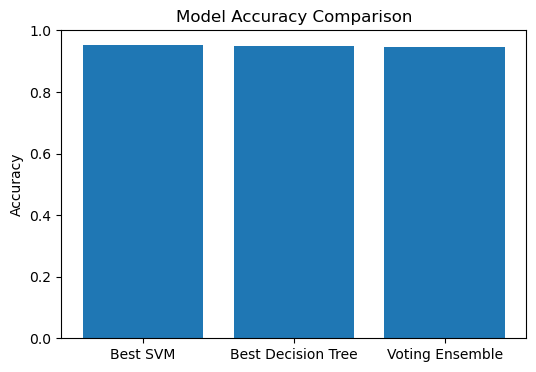

In [45]:
#Bar chart to compare the models's accuracy :
import matplotlib.pyplot as plt

accuracies = {name: accuracy_score(y_test, model.predict(X_test)) for name, model in models.items()}

plt.figure(figsize=(6,4))
plt.bar(accuracies.keys(), accuracies.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

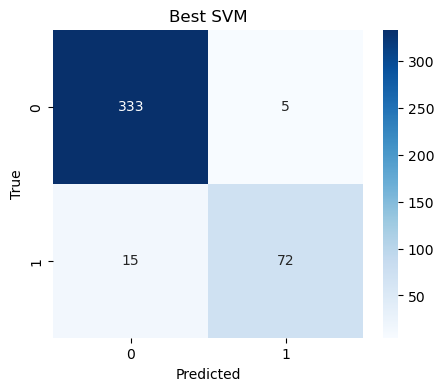

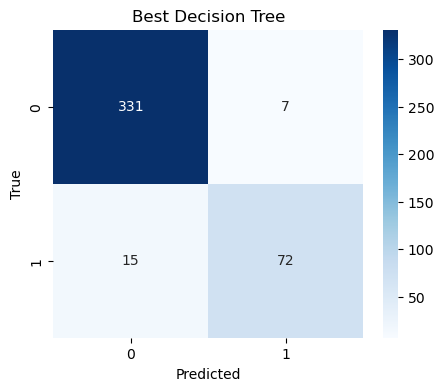

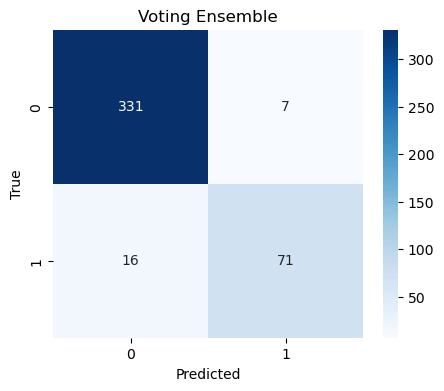

In [46]:
#Confusion Matrix :
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

The Best SVM achieved the highest accuracy (95.3%) and F1-score (0.878), indicating strong overall performance in correctly classifying both malignant and benign tumors. Its precision (0.935) shows that most predicted malignant cases were correct. However, SVM models are less interpretable due to their complex decision boundaries.

The Best Decision Tree performed slightly lower in accuracy (94.8%) and F1-score (0.867), but it remains highly interpretable. Decision Trees allow us to visualize and understand the decision rules, which is valuable in medical contexts. Its precision (0.911) is still strong, making it a reliable alternative.

The Voting Ensemble, combining the Bagging SVM and Bagging Decision Tree with soft voting, showed slightly lower accuracy (94.4%) and F1-score (0.855). This indicates that while ensembling can stabilize predictions, it does not necessarily improve metrics beyond the best individual model in this case. Its interpretability is medium, as it inherits some complexity from the SVM component.

If the priority is maximum accuracy, the Bagging SVM is the best choice. If interpretability is crucial, the Bagging Decision Tree is the preferred model. The Voting Ensemble offers a compromise but does not outperform the best individual model in this case.